PRÁCTICA MACHINE LEARNING: Predecir el mercado de valores

# Práctica Final - Predicción del Mercado de Valores

Trabajo con el dataset de Numerai para predecir rendimientos del mercado. El objetivo es entrenar un modelo que prediga el target (rendimientos a 20 días) basándose en las características proporcionadas.

Plan:
1. Cargar y explorar los datos
2. Entender la distribución de features y target
3. Entrenar diferentes modelos y compararlos
4. Evaluar el rendimiento
5. Generar predicciones finales

In [1]:
# Instala dependencias
%pip install -q --upgrade numerapi pandas pyarrow matplotlib lightgbm scikit-learn scipy cloudpickle==3.1.1

# Instalar numerai-tools (opcional, puede no estar disponible en algunos entornos)
# Si falla, simplemente continúa sin instalar este paquete
%pip install -q --no-deps numerai-tools

# Gráficas Inline
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


1.- DATASET

## Entendiendo el Dataset

El dataset es tabular y cada fila representa una acción en un momento específico:
- era: la fecha/semana del dato
- id: identificador único de la acción
- features: características numéricas que describen la acción (están anonimizadas)
- target: rendimientos a 20 días (lo que queremos predecir)

Los datos están ofuscados, así que no sabemos exactamente qué representa cada feature, pero está bien porque podemos enfocarnos en el modelo sin sesgos previos.

Descargamos los datos históricos de entrenamiento y echamos un vistazo de cerca.

In [2]:
# Inicializo NumerAPI
from numerapi import NumerAPI
napi = NumerAPI()

# Versión de datos
DATA_VERSION = "v5.0"

# Ver qué archivos están disponibles
[f for f in napi.list_datasets() if f.startswith(DATA_VERSION)]

['v5.0/features.json',
 'v5.0/live.parquet',
 'v5.0/live_benchmark_models.parquet',
 'v5.0/live_example_preds.csv',
 'v5.0/live_example_preds.parquet',
 'v5.0/meta_model.parquet',
 'v5.0/train.parquet',
 'v5.0/train_benchmark_models.parquet',
 'v5.0/validation.parquet',
 'v5.0/validation_benchmark_models.parquet',
 'v5.0/validation_example_preds.csv',
 'v5.0/validation_example_preds.parquet']

In [3]:
import pandas as pd
import json
import numpy as np

# Descargando los datos - esto puede tardar un poco
print("Descargando datos de entrenamiento...")
napi.download_dataset(f"{DATA_VERSION}/train.parquet")
napi.download_dataset(f"{DATA_VERSION}/features.json")

# Veo qué conjuntos de features hay disponibles
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]

print("\nFeatures disponibles:")
for fs_name in ["small", "medium", "all"]:
    print(f"  {fs_name}: {len(feature_sets[fs_name])} features")

# Empiezo con 'small' para iterar rápido, luego puedo probar con más features si hace falta
feature_set = feature_sets["small"]
print(f"\nUsando conjunto 'small' con {len(feature_set)} features")

# Cargamos solo las columnas que necesitamos para ahorrar memoria
train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)

print(f"\nDataset cargado: {train.shape[0]} filas, {train.shape[1]} columnas")

# Para reducir tiempo de entrenamiento, uso cada 4 eras
# Si funciona bien, podría entrenar con todas después
train = train[train["era"].isin(train["era"].unique()[::4])]
print(f"Después de filtrar: {train.shape[0]} filas")
print(f"Eras únicas: {train['era'].nunique()}")

# Vistazo rápido a los datos
print("\nPrimeras filas:")
train.head()

Descargando datos de entrenamiento...


2025-11-04 18:51:15,949 INFO numerapi.utils: target file already exists
2025-11-04 18:51:15,950 INFO numerapi.utils: download complete
2025-11-04 18:51:18,172 INFO numerapi.utils: target file already exists
2025-11-04 18:51:18,174 INFO numerapi.utils: download complete



Features disponibles:
  small: 42 features
  medium: 705 features
  all: 2376 features

Usando conjunto 'small' con 42 features

Dataset cargado: 2746270 filas, 44 columnas
Después de filtrar: 688184 filas
Eras únicas: 144

Primeras filas:


,era,target,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,...,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,0.25,2,2,2,2,2,0,1,2,...,4,1,1,3,0,2,2,3,3,2
n003bba8a98662e4,0001,0.25,2,2,2,2,2,1,4,2,...,4,2,0,0,0,2,2,4,4,2
n003bee128c2fcfc,0001,0.75,2,2,2,2,2,2,2,2,...,3,1,1,0,1,2,2,0,3,2
n0048ac83aff7194,0001,0.25,2,2,2,2,2,1,4,2,...,1,3,4,1,2,2,2,2,0,2
n0055a2401ba6480,0001,0.25,2,2,2,2,2,0,0,2,...,1,0,1,0,0,2,2,1,4,2


### Análisis Exploratorio Visual

Hago un análisis más visual para entender mejor la distribución de los datos antes de modelar.


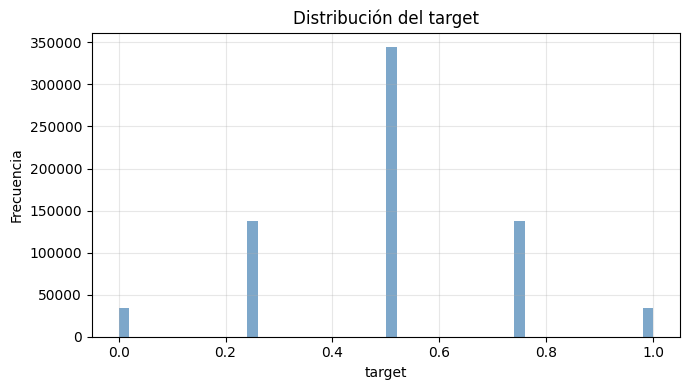

Valores únicos del target: [np.float32(0.0), np.float32(0.25), np.float32(0.5), np.float32(0.75), np.float32(1.0)]

Distribución del target:
target
0.00     33996
0.25    138070
0.50    344112
0.75    137929
1.00     34077
Name: count, dtype: int64

Interpretación:
El target está discretizado en bins: 0, 0.25, 0.5, 0.75, 1.0
Los valores están agrupados en 5 categorías, lo cual es importante para el modelado.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribución del target
plt.figure(figsize=(7, 4))
plt.hist(train['target'], bins=50, color='steelblue', alpha=0.7)
plt.title("Distribución del target")
plt.xlabel("target")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Valores únicos del target:", sorted(train["target"].unique()))
print("\nDistribución del target:")
print(train["target"].value_counts().sort_index())

print("\nInterpretación:")
print("El target está discretizado en bins: 0, 0.25, 0.5, 0.75, 1.0")
print("Los valores están agrupados en 5 categorías, lo cual es importante para el modelado.")


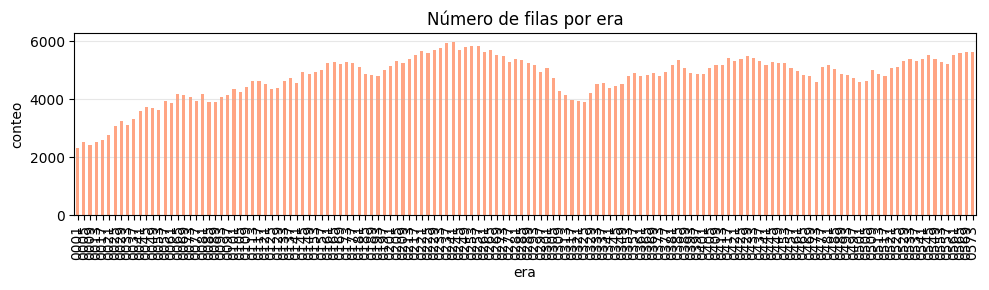

Promedio de filas por era: 4779
Desviación estándar: 768
Rango: [2316, 5988]

Interpretación:
El número de acciones por era es bastante constante.
Esto permite dividir los datos por era manteniendo la estructura temporal y evitando data leakage.


In [5]:
# Filas por era
plt.figure(figsize=(10, 3))
rows_per_era = train['era'].value_counts().sort_index()
rows_per_era.plot(kind='bar', color='coral', alpha=0.7)
plt.title("Número de filas por era")
plt.xlabel("era")
plt.ylabel("conteo")
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Promedio de filas por era: {rows_per_era.mean():.0f}")
print(f"Desviación estándar: {rows_per_era.std():.0f}")
print(f"Rango: [{rows_per_era.min()}, {rows_per_era.max()}]")

print("\nInterpretación:")
print("El número de acciones por era es bastante constante.")
print("Esto permite dividir los datos por era manteniendo la estructura temporal y evitando data leakage.")


In [6]:
# Muestra los primeros valores de era y target
print("Primeras filas del dataset:")
print(train[["era", "target"]].head(10))

print("\nInterpretación:")
print("Los datos se cargaron bien. Cada era tiene múltiples acciones con diferentes valores de target.")


Primeras filas del dataset:
                   era  target
id                            
n0007b5abb0c3a25  0001    0.25
n003bba8a98662e4  0001    0.25
n003bee128c2fcfc  0001    0.75
n0048ac83aff7194  0001    0.25
n0055a2401ba6480  0001    0.25
n00691bec80d3e02  0001    0.75
n00af797ddc6cd61  0001    0.50
n00b8720a2fdc4f2  0001    0.75
n00ef35a00c37b0e  0001    0.00
n012104f137c388a  0001    0.50

Interpretación:
Los datos se cargaron bien. Cada era tiene múltiples acciones con diferentes valores de target.


ERAS:

Como se mencionó anteriormente, cada "era" corresponde a una fecha diferente. Cada "era" tiene exactamente una semana de diferencia.

Es útil pensar en filas de acciones dentro de la misma "era" como un solo ejemplo. A lo largo de este notebook hablaremos de cosas "por era". Por ejemplo, el número de filas por "era" representa el conjunto de acciones (stocks) dentro de las posibilidades de inversión de algún fondo en esa fecha.

Promedio de filas por era: 4779
Desviación estándar: 768
Rango: [2316, 5988]


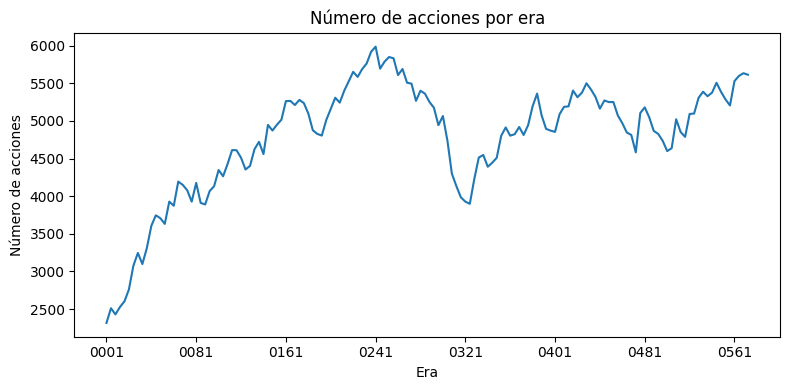

In [7]:
import matplotlib.pyplot as plt

# Veamos cuántas acciones hay por era - esto debería ser relativamente constante
rows_per_era = train.groupby("era").size()
print(f"Promedio de filas por era: {rows_per_era.mean():.0f}")
print(f"Desviación estándar: {rows_per_era.std():.0f}")
print(f"Rango: [{rows_per_era.min()}, {rows_per_era.max()}]")

rows_per_era.plot(title="Número de acciones por era", figsize=(8, 4), xlabel="Era", ylabel="Número de acciones")
plt.tight_layout()
plt.show()

FEATURES:

Como se mencionó anteriormente, las características son atributos cuantitativos de cada acción: fundamentos como la relación P/E (precio/beneficio), señales técnicas como el RSI, datos de mercado como el interés a corto, datos secundarios como las calificaciones de los analistas y mucho más.

La definición subyacente de cada característica no es importante, solo debes saber que se han incluido estas características en el conjunto de datos porque se cree que pueden ser relevantes para predecir el "target".

In [8]:
# Verificando cuántas features tenemos
print(f"Total de features: {len(feature_set)}")
print(f"\nAlgunas features de ejemplo:")
print(feature_set[:5])

Total de features: 42

Algunas features de ejemplo:
['feature_antistrophic_striate_conscriptionist', 'feature_bicameral_showery_wallaba', 'feature_bridal_fingered_pensioner', 'feature_collectivist_flaxen_gueux', 'feature_concurring_fabled_adapter']


Los valores de las características se agrupan en 5 contenedores iguales: 0, 1, 2, 3, 4. Esta fuerte estandarización de los valores de las características tiene como objetivo evitar el overfitting, ya que los valores subyacentes son extremadamente ruidosos.

Si faltan datos de una característica particular para esa era (más común en las primeras eras), todos los valores se establecen en 2.


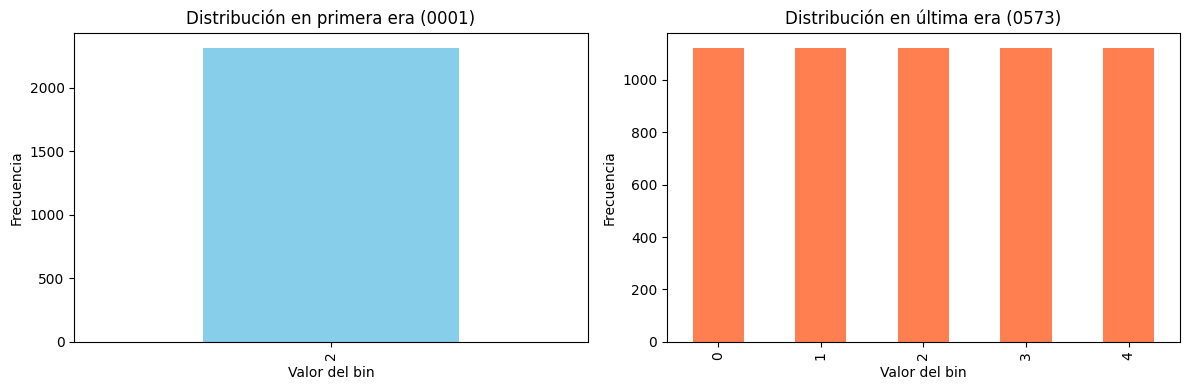

Primera era - valores únicos: [np.int8(2)]
Última era - valores únicos: [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4)]


In [9]:
# Las features están discretizadas en bins 0-4
# Veamos cómo se distribuye una feature en la primera y última era
import matplotlib.pyplot as plt

first_era = train[train["era"] == train["era"].unique()[0]]
last_era = train[train["era"] == train["era"].unique()[-1]]
sample_feature = feature_set[-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Primera era - puede tener más valores en 2 (missing data)
first_era[sample_feature].value_counts().sort_index().plot(kind="bar", ax=ax1, color='skyblue')
ax1.set_title(f"Distribución en primera era ({train['era'].unique()[0]})")
ax1.set_xlabel("Valor del bin")
ax1.set_ylabel("Frecuencia")

# Última era - debería tener mejor distribución
last_era[sample_feature].value_counts().sort_index().plot(kind="bar", ax=ax2, color='coral')
ax2.set_title(f"Distribución en última era ({train['era'].unique()[-1]})")
ax2.set_xlabel("Valor del bin")
ax2.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# Estadísticas rápidas
print(f"Primera era - valores únicos: {sorted(first_era[sample_feature].unique())}")
print(f"Última era - valores únicos: {sorted(last_era[sample_feature].unique())}")

TARGET:

El "target" es una medida de los rendimientos del mercado de valores a 20 días. Es una medida de rendimientos "específicos de acciones" que no se explican por tendencias más amplias en el mercado, país, sector o factores bien conocidos.

Los valores del "target" se agrupan en 5 contenedores desiguales: 0, 0,25, 0,5, 0,75, 1,0. Esta estandarización tiene como objetivo evitar el overfitting, ya que los valores subyacentes son extremadamente ruidosos.

## Análisis Exploratorio Detallado

Hago un análisis más profundo para entender mejor los datos antes de modelar.


Análisis de valores faltantes:
Features con valores faltantes: 0
No hay valores faltantes

Variabilidad de features:
  Max varianza: 2.0634
  Min varianza: 1.2041
  Media varianza: 1.8880


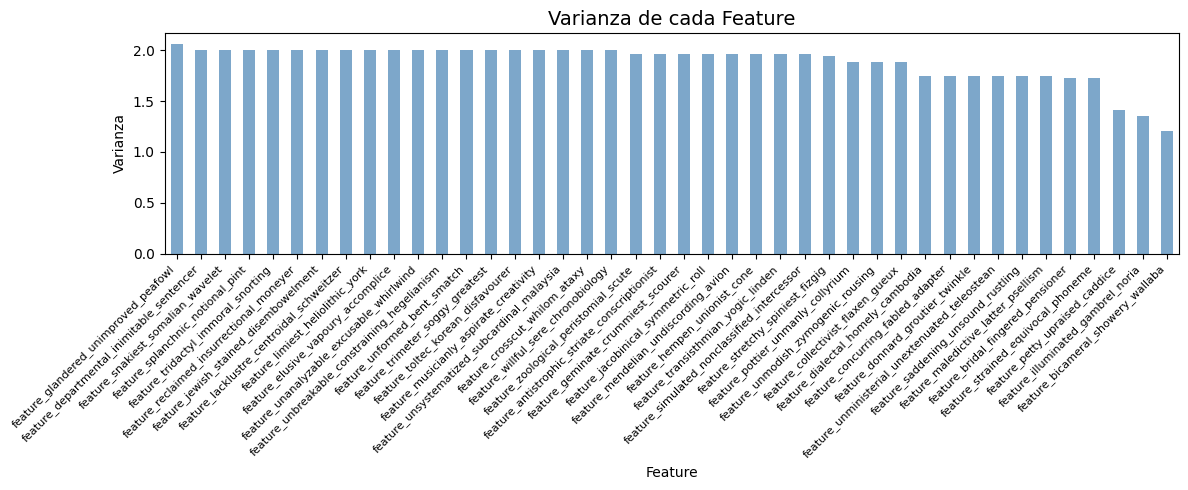


Features con varianza muy baja (< 0.1): 0


In [10]:
# Análisis de valores faltantes
print("Análisis de valores faltantes:")
missing_data = train[feature_set].isnull().sum()
print(f"Features con valores faltantes: {(missing_data > 0).sum()}")
if (missing_data > 0).any():
    print(missing_data[missing_data > 0])
else:
    print("No hay valores faltantes")

# Análisis de varianza de features
feature_variance = train[feature_set].var().sort_values(ascending=False)
print(f"\nVariabilidad de features:")
print(f"  Max varianza: {feature_variance.max():.4f}")
print(f"  Min varianza: {feature_variance.min():.4f}")
print(f"  Media varianza: {feature_variance.mean():.4f}")

# Visualización de varianza
plt.figure(figsize=(10, 6))
feature_variance.plot(kind='bar', figsize=(12, 5), color='steelblue', alpha=0.7)
plt.title('Varianza de cada Feature', fontsize=14)
plt.xlabel('Feature')
plt.ylabel('Varianza')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

# Features con poca varianza pueden ser menos informativas
low_variance_features = feature_variance[feature_variance < 0.1]
print(f"\nFeatures con varianza muy baja (< 0.1): {len(low_variance_features)}")
if len(low_variance_features) > 0:
    print("Estas features aportan poca información:", list(low_variance_features.index))


Calculando correlaciones con el target...

Top 10 features más correlacionadas con el target:
feature_snakiest_somalian_wavelet              0.010715
feature_trimeter_soggy_greatest                0.009701
feature_willful_sere_chronobiology             0.009490
feature_jewish_stained_disembowelment          0.009227
feature_stretchy_spiniest_fizgig               0.007674
feature_pottier_unmanly_collyrium              0.007612
feature_departmental_inimitable_sentencer      0.007156
feature_transisthmian_yogic_linden             0.006980
feature_musicianly_aspirate_creativity         0.006951
feature_simulated_nonclassified_intercessor    0.006767
dtype: float64


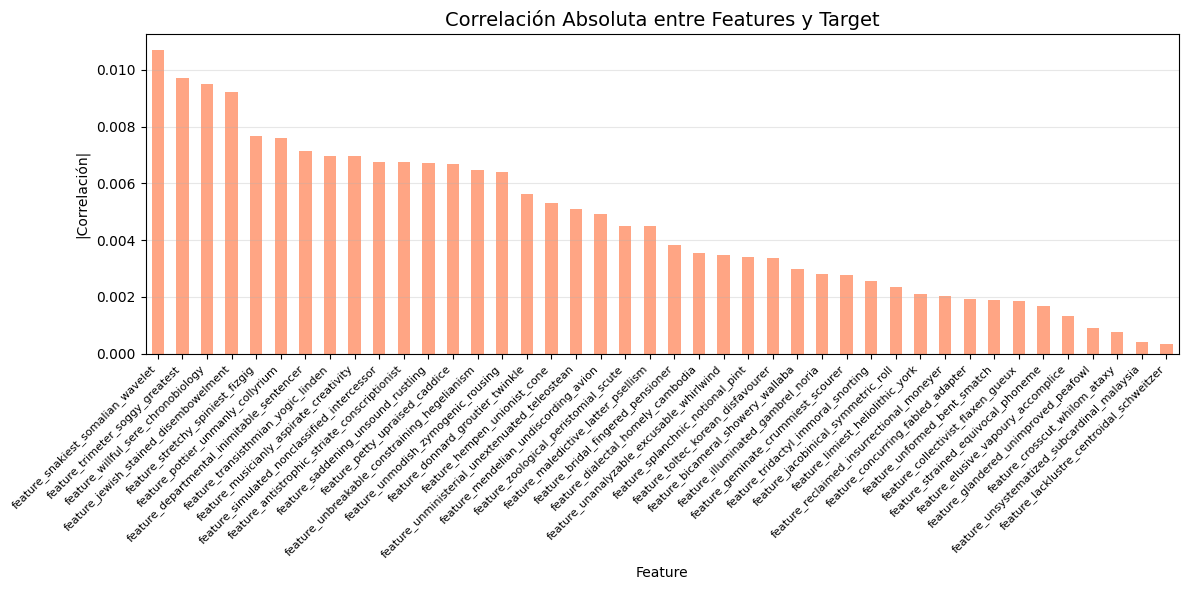


Features con correlación muy baja con target (< 0.01): 41
Estas features probablemente no aporten mucho para predecir el target


In [11]:
# Análisis de correlación entre features y target
print("Calculando correlaciones con el target...")
target_correlations = train[feature_set].apply(lambda x: np.corrcoef(x, train["target"])[0, 1]).abs().sort_values(ascending=False)

print(f"\nTop 10 features más correlacionadas con el target:")
print(target_correlations.head(10))

# Visualización
plt.figure(figsize=(12, 6))
target_correlations.plot(kind='bar', color='coral', alpha=0.7)
plt.title('Correlación Absoluta entre Features y Target', fontsize=14)
plt.xlabel('Feature')
plt.ylabel('|Correlación|')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Features con muy baja correlación con el target
low_corr_threshold = 0.01
low_corr_features = target_correlations[target_correlations < low_corr_threshold]
print(f"\nFeatures con correlación muy baja con target (< {low_corr_threshold}): {len(low_corr_features)}")
print("Estas features probablemente no aporten mucho para predecir el target")


### Preprocesamiento

Las features ya están discretizadas en bins 0-4, así que están en la misma escala. No necesito escalado adicional.

Elimino features con muy baja correlación con el target y/o muy baja varianza, ya que probablemente no aporten información útil.


In [12]:
# === PREPARACIÓN DE DATOS PARA MODELADO ===
# Esta celda define las variables necesarias antes de entrenar los modelos

from scipy import stats
from sklearn.model_selection import train_test_split

# 1. Definir función de correlación personalizada
def practica_corr(preds, target):
    # clasifica (manteniendo vínculos) y luego gaussianiza las predicciones para estandarizar las distribuciones de predicción
    ranked_preds = (preds.rank(method="average").values - 0.5) / preds.count()
    gauss_ranked_preds = stats.norm.ppf(ranked_preds)
    # centra objetivos alrededor de 0
    centered_target = target - target.mean()
    # Levanta ambas predicciones y apunta a la potencia de 1,5 para acentuar las colas.
    preds_p15 = np.sign(gauss_ranked_preds) * np.abs(gauss_ranked_preds) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    # Finalmente devuelve el Pearson correlation
    return np.corrcoef(preds_p15, target_p15)[0, 1]

# 2. Selección de características: eliminando las menos relevantes
# Criterio: eliminar features con correlación con target < 0.005 Y varianza < 0.05
corr_threshold = 0.005
variance_threshold = 0.05

features_to_remove = []
for feat in feature_set:
    corr_with_target = abs(np.corrcoef(train[feat], train["target"])[0, 1])
    variance = train[feat].var()
    
    if corr_with_target < corr_threshold and variance < variance_threshold:
        features_to_remove.append(feat)

print(f"Features a eliminar por baja relevancia: {len(features_to_remove)}")
if features_to_remove:
    print(f"Eliminando: {features_to_remove}")

# Creo un nuevo conjunto de features filtrado
selected_features = [f for f in feature_set if f not in features_to_remove]
print(f"\nFeatures originales: {len(feature_set)}")
print(f"Features seleccionadas: {len(selected_features)}")
print(f"Reducción: {len(features_to_remove)} features eliminadas ({100*len(features_to_remove)/len(feature_set):.1f}%)")

# 3. División de datos en train/test
# Dividimos por era para mantener la estructura temporal
eras = train["era"].unique()
eras_train = eras[:int(len(eras) * 0.8)]
eras_test = eras[int(len(eras) * 0.8):]

train_split = train[train["era"].isin(eras_train)]
test_split = train[train["era"].isin(eras_test)]

# Separar características y target
X_train_full = train_split[selected_features].values
y_train_full = train_split["target"].values
X_test_split = test_split[selected_features].values
y_test_split = test_split["target"].values

print(f"\nDivisión de datos:")
print(f"  Train: {len(train_split)} muestras ({len(eras_train)} eras)")
print(f"  Test: {len(test_split)} muestras ({len(eras_test)} eras)")

# Guardo test_split como DataFrame completo para poder calcular correlación por era
# (necesario para la función practica_corr)


Features a eliminar por baja relevancia: 0

Features originales: 42
Features seleccionadas: 42
Reducción: 0 features eliminadas (0.0%)

División de datos:
  Train: 539937 muestras (115 eras)
  Test: 148247 muestras (29 eras)


#### Sobre el Overfitting

Overfitting ocurre cuando el modelo aprende demasiado los detalles del entrenamiento, incluyendo el ruido. Funciona bien en train pero mal en datos nuevos.

Cómo lo evito:
1. Regularización: uso colsample_bytree=0.1 para que cada árbol use solo 10% de features
2. Learning rate bajo: 0.01 para que aprenda más gradualmente
3. Profundidad limitada: max_depth=5 previene árboles demasiado complejos
4. Validación temprana: uso datos de test separados
5. Ridge tiene regularización L2 incorporada
6. PCA reduce la dimensionalidad


In [13]:
import lightgbm as lgb
import warnings
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')

# === MODELO 1: LightGBM con features originales filtradas ===
print("=" * 60)
print("MODELO 1: LightGBM con features seleccionadas")
print("=" * 60)

model_lgbm = lgb.LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.01,
    max_depth=5,
    num_leaves=2**5-1,
    colsample_bytree=0.1,
    random_state=42,
    verbose=-1
)

print(f"\nEntrenando con {len(X_train_full)} muestras y {len(selected_features)} features...")
model_lgbm.fit(X_train_full, y_train_full)
print("Entrenamiento completado!")

# Predicciones en test
pred_test_lgbm = model_lgbm.predict(X_test_split)
pred_train_lgbm = model_lgbm.predict(X_train_full)

# Métricas básicas en train y test
train_rmse_lgbm = np.sqrt(mean_squared_error(y_train_full, pred_train_lgbm))
test_rmse_lgbm = np.sqrt(mean_squared_error(y_test_split, pred_test_lgbm))

print(f"\nRMSE Train: {train_rmse_lgbm:.6f}")
print(f"RMSE Test: {test_rmse_lgbm:.6f}")
print(f"Diferencia (indica overfitting si es muy grande): {abs(train_rmse_lgbm - test_rmse_lgbm):.6f}")

# Correlación en test (usando la métrica de la práctica)
test_corr_lgbm = test_split.groupby("era", group_keys=False).apply(
    lambda x: practica_corr(pd.Series(model_lgbm.predict(x[selected_features])), x["target"])
)
print(f"Correlación promedio en test: {test_corr_lgbm.mean():.5f}")


MODELO 1: LightGBM con features seleccionadas

Entrenando con 539937 muestras y 42 features...
Entrenamiento completado!

RMSE Train: 0.222576
RMSE Test: 0.222974
Diferencia (indica overfitting si es muy grande): 0.000397
Correlación promedio en test: 0.03075


In [14]:
# === MODELO 2: LightGBM con PCA ===
print("\n" + "=" * 60)
print("MODELO 2: LightGBM con PCA")
print("=" * 60)

# Primero definimos scaler y PCA con los datos de entrenamiento
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Escalamos los datos de entrenamiento
scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train_full)

# Aplicamos PCA - retenemos el 95% de la varianza explicada
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)

# Aplicamos el mismo scaler y PCA al test split
X_test_pca = pca.transform(scaler_pca.transform(X_test_split))

print(f"Features originales: {X_train_full.shape[1]}")
print(f"Componentes PCA (95% varianza): {X_train_pca.shape[1]}")
print(f"Varianza explicada acumulada: {pca.explained_variance_ratio_.sum():.4f}")

model_lgbm_pca = lgb.LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.01,
    max_depth=5,
    num_leaves=2**5-1,
    colsample_bytree=0.15,  # Ajustado porque tenemos menos features ahora
    random_state=42,
    verbose=-1
)

print(f"\nEntrenando con {len(X_train_pca)} muestras y {X_train_pca.shape[1]} componentes PCA...")
model_lgbm_pca.fit(X_train_pca, y_train_full)
print("Entrenamiento completado!")

pred_test_lgbm_pca = model_lgbm_pca.predict(X_test_pca)
pred_train_lgbm_pca = model_lgbm_pca.predict(X_train_pca)

train_rmse_lgbm_pca = np.sqrt(mean_squared_error(y_train_full, pred_train_lgbm_pca))
test_rmse_lgbm_pca = np.sqrt(mean_squared_error(y_test_split, pred_test_lgbm_pca))

print(f"\nRMSE Train: {train_rmse_lgbm_pca:.6f}")
print(f"RMSE Test: {test_rmse_lgbm_pca:.6f}")
print(f"Diferencia: {abs(train_rmse_lgbm_pca - test_rmse_lgbm_pca):.6f}")

test_corr_lgbm_pca = test_split.groupby("era", group_keys=False).apply(
    lambda x: practica_corr(
        pd.Series(model_lgbm_pca.predict(pca.transform(scaler_pca.transform(x[selected_features])))),
        x["target"]
    )
)
print(f"Correlación promedio en test: {test_corr_lgbm_pca.mean():.5f}")



MODELO 2: LightGBM con PCA
Features originales: 42
Componentes PCA (95% varianza): 36
Varianza explicada acumulada: 0.9551

Entrenando con 539937 muestras y 36 componentes PCA...
Entrenamiento completado!

RMSE Train: 0.221824
RMSE Test: 0.223020
Diferencia: 0.001195
Correlación promedio en test: 0.02584


### División Temporal por Eras

¿Por qué dividimos por eras y no hacemos un split aleatorio?

En problemas financieros es importante mantener la estructura temporal. Un split aleatorio causaría data leakage porque:

1. Si mezclamos datos de diferentes eras, el modelo podría "ver" información del futuro durante el entrenamiento, lo cual no es realista.

2. Las eras representan períodos de tiempo específicos. Dividir por eras (80% train, 20% test) asegura que entrenamos con datos históricos y evaluamos con datos futuros.

3. Esto nos permite evaluar si el modelo generaliza bien a períodos que no ha visto.

Dividimos los datos manteniendo el orden temporal: 80% de las eras más antiguas para entrenamiento y 20% de las más recientes para evaluación.


In [15]:
# === MODELO 3: Ridge Regression ===
print("\n" + "=" * 60)
print("MODELO 3: Ridge Regression")
print("=" * 60)

# Ridge usa regularización L2 que penaliza coeficientes grandes
# Esto ayuda a evitar overfitting cuando hay muchas features correlacionadas
# Es un buen complemento a LightGBM que puede sobreajustar en datos ruidosos

# Ridge funciona mejor con datos escalados
# Definimos y ajustamos el scaler con los datos de entrenamiento
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_split)

# Entreno Ridge con diferentes valores de alpha (regularización)
best_alpha = None
best_score = -np.inf

print("\nBuscando mejor alpha (regularización)...")
for alpha in [0.1, 1.0, 10.0, 100.0]:
    model_ridge_temp = Ridge(alpha=alpha, random_state=42)
    model_ridge_temp.fit(X_train_scaled, y_train_full)
    
    # Evaluar con correlación en test (nuestra métrica)
    pred_temp = model_ridge_temp.predict(X_test_scaled)
    corr_temp = test_split.groupby("era", group_keys=False).apply(
        lambda x: practica_corr(
            pd.Series(model_ridge_temp.predict(scaler.transform(x[selected_features]))),
            x["target"]
        )
    ).mean()
    
    print(f"  Alpha={alpha:6.1f}: Correlación={corr_temp:.5f}")
    if corr_temp > best_score:
        best_score = corr_temp
        best_alpha = alpha

print(f"\nMejor alpha: {best_alpha}")

model_ridge = Ridge(alpha=best_alpha, random_state=42)
model_ridge.fit(X_train_scaled, y_train_full)

pred_test_ridge = model_ridge.predict(X_test_scaled)
pred_train_ridge = model_ridge.predict(X_train_scaled)

train_rmse_ridge = np.sqrt(mean_squared_error(y_train_full, pred_train_ridge))
test_rmse_ridge = np.sqrt(mean_squared_error(y_test_split, pred_test_ridge))

print(f"\nRMSE Train: {train_rmse_ridge:.6f}")
print(f"RMSE Test: {test_rmse_ridge:.6f}")
print(f"Diferencia: {abs(train_rmse_ridge - test_rmse_ridge):.6f}")

test_corr_ridge = test_split.groupby("era", group_keys=False).apply(
    lambda x: practica_corr(
        pd.Series(model_ridge.predict(scaler.transform(x[selected_features]))),
        x["target"]
    )
)
print(f"Correlación promedio en test: {test_corr_ridge.mean():.5f}")



MODELO 3: Ridge Regression

Buscando mejor alpha (regularización)...
  Alpha=   0.1: Correlación=0.02815
  Alpha=   1.0: Correlación=0.02815
  Alpha=  10.0: Correlación=0.02815
  Alpha= 100.0: Correlación=0.02815

Mejor alpha: 100.0

RMSE Train: 0.223018
RMSE Test: 0.223002
Diferencia: 0.000015
Correlación promedio en test: 0.02815


### Métrica de Evaluación: Correlación Pearson por Era

¿Por qué usamos correlación de Pearson y no F1-score?

En este problema el objetivo es una variable continua (rendimientos a 20 días), así que usamos correlación de Pearson que mide la relación lineal entre predicciones y valores reales.

- Correlación de Pearson: Mide qué tan bien las predicciones siguen el patrón de los valores reales. Es apropiada para regresión.

- F1-score: Se usa solo en clasificación, no en regresión.

Evaluamos por era para asegurar que el modelo funciona consistentemente a lo largo del tiempo.



VALIDACIÓN: Correlación por Era

Media de correlación por era:
  LightGBM:  0.03283
  Ridge:     0.02946


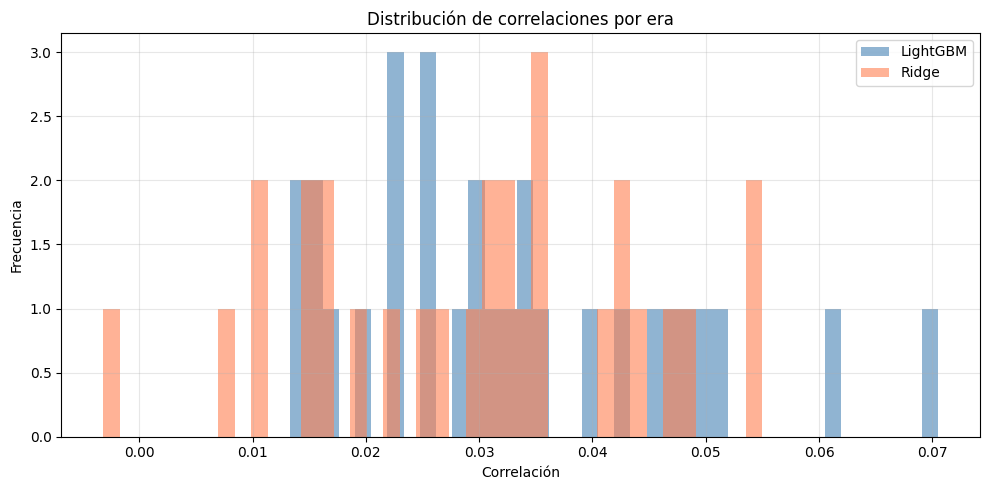


Comparación completada. Ambos modelos muestran su rendimiento por era.


In [16]:
# === Validación: Correlación por Era para ambos modelos ===
print("\n" + "=" * 60)
print("VALIDACIÓN: Correlación por Era")
print("=" * 60)

# Función para calcular correlación por era
def era_corr(df_true, preds):
    """Calcula la correlación de Pearson por era"""
    df_temp = df_true.copy()
    df_temp["pred"] = preds
    return df_temp.groupby("era").apply(lambda d: d["target"].corr(d["pred"]))

# Correlaciones por era para ambos modelos
corr_lgbm = era_corr(test_split, pred_test_lgbm)
corr_ridge = era_corr(test_split, pred_test_ridge)

print("\nMedia de correlación por era:")
print(f"  LightGBM:  {np.nanmean(corr_lgbm):.5f}")
print(f"  Ridge:     {np.nanmean(corr_ridge):.5f}")

# Visualización: Distribución de correlaciones por era
plt.figure(figsize=(10, 5))
plt.hist(corr_lgbm, bins=40, alpha=0.6, label="LightGBM", color='steelblue')
plt.hist(corr_ridge, bins=40, alpha=0.6, label="Ridge", color='coral')
plt.legend()
plt.title("Distribución de correlaciones por era")
plt.xlabel("Correlación")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nComparación completada. Ambos modelos muestran su rendimiento por era.")



COMPARACIÓN DE MODELOS
                       Modelo  Features/Componentes  RMSE Train  RMSE Test  Correlación Test
LightGBM (features filtradas)                    42    0.222576   0.222974          0.030745
               LightGBM (PCA)                    36    0.221824   0.223020          0.025835
             Ridge Regression                    42    0.223018   0.223002          0.028149


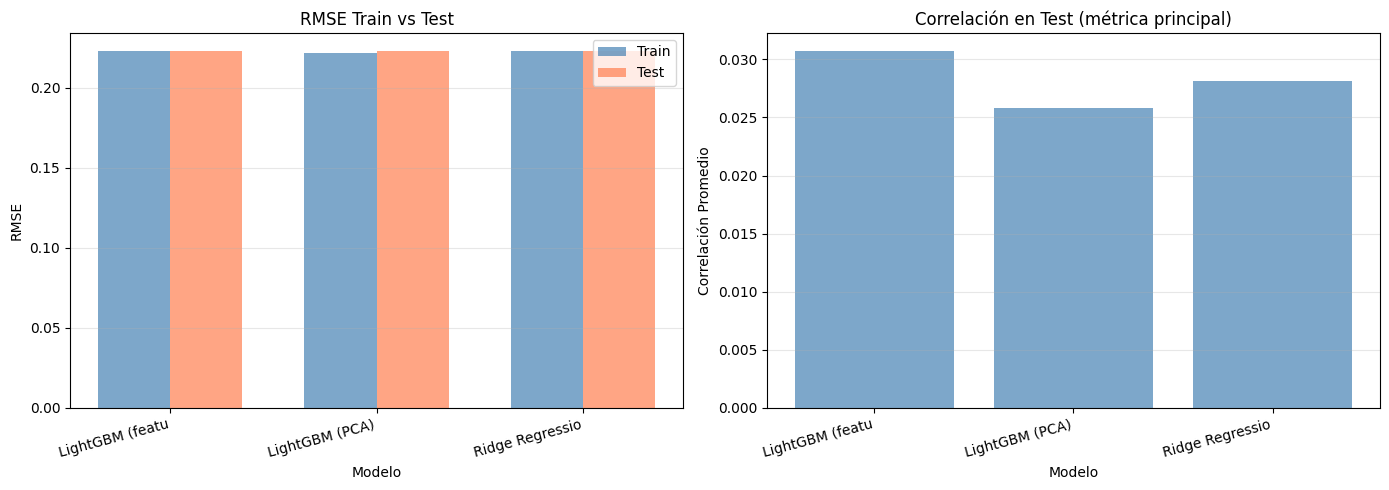


Mejor modelo según correlación en test: LightGBM (features filtradas)
   Correlación: 0.03075


In [17]:
# Comparación de modelos
comparison = pd.DataFrame({
    'Modelo': ['LightGBM (features filtradas)', 'LightGBM (PCA)', 'Ridge Regression'],
    'Features/Componentes': [len(selected_features), X_train_pca.shape[1], len(selected_features)],
    'RMSE Train': [train_rmse_lgbm, train_rmse_lgbm_pca, train_rmse_ridge],
    'RMSE Test': [test_rmse_lgbm, test_rmse_lgbm_pca, test_rmse_ridge],
    'Correlación Test': [test_corr_lgbm.mean(), test_corr_lgbm_pca.mean(), test_corr_ridge.mean()]
})

print("\n" + "=" * 80)
print("COMPARACIÓN DE MODELOS")
print("=" * 80)
print(comparison.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: RMSE
ax1 = axes[0]
x_pos = np.arange(len(comparison))
width = 0.35
ax1.bar(x_pos - width/2, comparison['RMSE Train'], width, label='Train', alpha=0.7, color='steelblue')
ax1.bar(x_pos + width/2, comparison['RMSE Test'], width, label='Test', alpha=0.7, color='coral')
ax1.set_xlabel('Modelo')
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE Train vs Test')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([m[:15] for m in comparison['Modelo']], rotation=15, ha='right')
ax1.legend()
ax1.grid(alpha=0.3, axis='y')

# Gráfico 2: Correlación
ax2 = axes[1]
ax2.bar(range(len(comparison)), comparison['Correlación Test'], color='steelblue', alpha=0.7)
ax2.set_xlabel('Modelo')
ax2.set_ylabel('Correlación Promedio')
ax2.set_title('Correlación en Test (métrica principal)')
ax2.set_xticks(range(len(comparison)))
ax2.set_xticklabels([m[:15] for m in comparison['Modelo']], rotation=15, ha='right')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Decidir qué modelo usar
best_model_idx = comparison['Correlación Test'].idxmax()
best_model_name = comparison.loc[best_model_idx, 'Modelo']
print(f"\nMejor modelo según correlación en test: {best_model_name}")
print(f"   Correlación: {comparison.loc[best_model_idx, 'Correlación Test']:.5f}")

# Guardamos qué modelo usar para validación final
if 'PCA' in best_model_name:
    final_model = model_lgbm_pca
    use_pca = True
    model_type = 'lgbm_pca'
elif 'Ridge' in best_model_name:
    final_model = model_ridge
    use_pca = False
    model_type = 'ridge'
else:
    final_model = model_lgbm
    use_pca = False
    model_type = 'lgbm'


In [18]:
# Selección de características: eliminando las menos relevantes
# Criterio: eliminar features con correlación con target < 0.005 Y varianza < 0.05
corr_threshold = 0.005
variance_threshold = 0.05

features_to_remove = []
for feat in feature_set:
    corr_with_target = abs(np.corrcoef(train[feat], train["target"])[0, 1])
    variance = train[feat].var()
    
    if corr_with_target < corr_threshold and variance < variance_threshold:
        features_to_remove.append(feat)

print(f"Features a eliminar por baja relevancia: {len(features_to_remove)}")
if features_to_remove:
    print(f"Eliminando: {features_to_remove}")

# Creo un nuevo conjunto de features filtrado
selected_features = [f for f in feature_set if f not in features_to_remove]
print(f"\nFeatures originales: {len(feature_set)}")
print(f"Features seleccionadas: {len(selected_features)}")
print(f"Reducción: {len(features_to_remove)} features eliminadas ({100*len(features_to_remove)/len(feature_set):.1f}%)")

# Guardamos ambas versiones para comparar después
feature_set_filtered = selected_features


Features a eliminar por baja relevancia: 0

Features originales: 42
Features seleccionadas: 42
Reducción: 0 features eliminadas (0.0%)


Features originales: 42
Componentes PCA (95% varianza): 36
Varianza explicada acumulada:
  Primeros 5 componentes: 0.2972
  Total (95% varianza): 0.9558


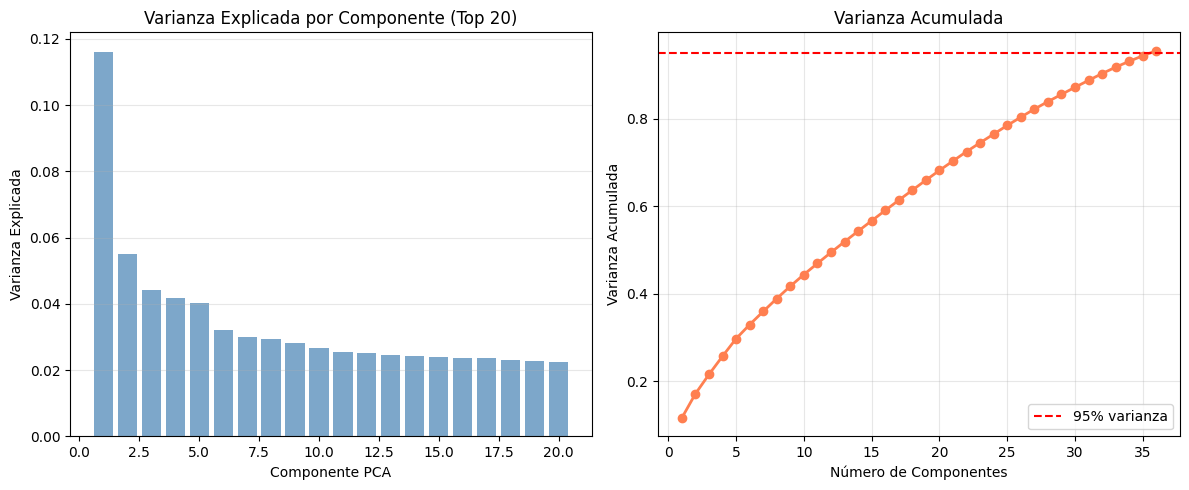


Con PCA, reducimos de 42 a 36 componentes, manteniendo el 95% de la varianza.
Esto puede ayudar a reducir overfitting y acelerar el entrenamiento.


In [19]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Esta celda es solo para análisis/exploración de PCA
# Los modelos usan sus propias definiciones de scaler y pca en sus respectivas celdas
# Usamos nombres diferentes aquí para evitar conflictos

# Preparo los datos (aunque ya están discretizados, aplico StandardScaler para PCA)
X_full = train[selected_features].values
scaler_exploration = StandardScaler()  # Renombrado para evitar conflictos
X_scaled_exploration = scaler_exploration.fit_transform(X_full)

# Aplico PCA - retengo el 95% de la varianza explicada
pca_exploration = PCA(n_components=0.95)  # Renombrado para evitar conflictos
X_pca_exploration = pca_exploration.fit_transform(X_scaled_exploration)

print(f"Features originales: {X_full.shape[1]}")
print(f"Componentes PCA (95% varianza): {X_pca_exploration.shape[1]}")
print(f"Varianza explicada acumulada:")
print(f"  Primeros 5 componentes: {pca_exploration.explained_variance_ratio_[:5].sum():.4f}")
print(f"  Total (95% varianza): {pca_exploration.explained_variance_ratio_.sum():.4f}")

# Visualización de varianza explicada
plt.figure(figsize=(12, 5))

# Gráfico 1: Varianza explicada por cada componente
plt.subplot(1, 2, 1)
variance_ratio = pca_exploration.explained_variance_ratio_[:20]  # Primeros 20 para visualización
plt.bar(range(1, len(variance_ratio) + 1), variance_ratio, color='steelblue', alpha=0.7)
plt.xlabel('Componente PCA')
plt.ylabel('Varianza Explicada')
plt.title('Varianza Explicada por Componente (Top 20)')
plt.grid(alpha=0.3, axis='y')

# Gráfico 2: Varianza acumulada
plt.subplot(1, 2, 2)
cumulative_variance = np.cumsum(pca_exploration.explained_variance_ratio_)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linewidth=2, color='coral')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% varianza')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.title('Varianza Acumulada')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCon PCA, reducimos de {len(selected_features)} a {X_pca_exploration.shape[1]} componentes, manteniendo el 95% de la varianza.")
print(f"Esto puede ayudar a reducir overfitting y acelerar el entrenamiento.")


### Reducción de Dimensionalidad con PCA

Aplico PCA para reducir la dimensionalidad y ver si mejora el rendimiento. PCA puede ayudar cuando hay muchas features correlacionadas.


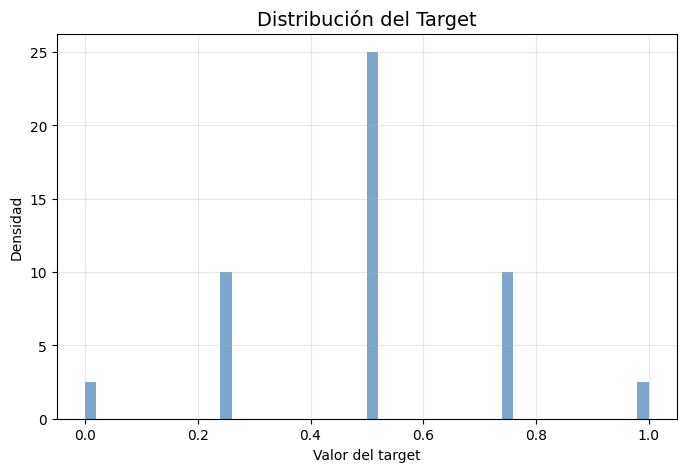

Valores únicos del target: [np.float32(0.0), np.float32(0.25), np.float32(0.5), np.float32(0.75), np.float32(1.0)]

Distribución:
target
0.00     33996
0.25    138070
0.50    344112
0.75    137929
1.00     34077
Name: count, dtype: int64


In [20]:
# El target está discretizado en bins: 0, 0.25, 0.5, 0.75, 1.0
# Veamos su distribución
plt.figure(figsize=(8, 5))
train["target"].plot(kind="hist", bins=50, density=True, alpha=0.7, color='steelblue')
plt.title("Distribución del Target", fontsize=14)
plt.xlabel("Valor del target")
plt.ylabel("Densidad")
plt.grid(alpha=0.3)
plt.show()

print("Valores únicos del target:", sorted(train["target"].unique()))
print("\nDistribución:")
print(train["target"].value_counts().sort_index())

### Reducción de Datos de Entrenamiento

El dataset es muy grande. Uso solo cada 4 eras porque:

- El dataset completo tiene millones de filas
- Cada era tiene aproximadamente el mismo número de acciones
- Usar todas las eras tomaría mucho tiempo
- Cada 4 eras = aproximadamente cada mes, mantiene diversidad temporal
- Si el modelo funciona bien, después podría entrenar con más datos

Uso esta reducción para poder iterar más rápido y probar diferentes enfoques.


2.- MODELING

## Entrenamiento del Modelo

Uso LightGBM porque es rápido con datasets grandes y maneja bien features discretizadas. Empiezo con parámetros conservadores y luego puedo ajustar si hace falta.

In [21]:
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Preparando los datos para entrenar
X_train = train[feature_set]
y_train = train["target"]

print(f"Entrenando con {len(X_train)} muestras y {len(feature_set)} features")
print(f"Eras de entrenamiento: {train['era'].nunique()}")

# Parámetros iniciales - empiezo conservador para evitar overfitting
# Luego puedo ajustar según resultados
model = lgb.LGBMRegressor(
    n_estimators=2000,          # Muchos árboles con learning rate bajo
    learning_rate=0.01,          # Learning rate pequeño para entrenamiento más suave
    max_depth=5,                 # Profundidad moderada
    num_leaves=2**5-1,           # 31 leaves, consistente con max_depth
    colsample_bytree=0.1,        # Usa solo 10% de features por árbol (reduce overfitting)
    random_state=42,             # Para reproducibilidad
    verbose=-1                   # Menos output
)

print("\nIniciando entrenamiento...")
model.fit(X_train, y_train)
print("¡Entrenamiento completado!")

Entrenando con 688184 muestras y 42 features
Eras de entrenamiento: 144

Iniciando entrenamiento...
¡Entrenamiento completado!


Top 10 features más importantes:
                                  feature  importance
       feature_jacobinical_symmetric_roll        3458
       feature_geminate_crummiest_scourer        3329
 feature_unanalyzable_excusable_whirlwind        3266
        feature_toltec_korean_disfavourer        3213
        feature_pottier_unmanly_collyrium        3149
        feature_bridal_fingered_pensioner        3033
feature_departmental_inimitable_sentencer        2919
      feature_maledictive_latter_psellism        2901
       feature_unmodish_zymogenic_rousing        2889
        feature_snakiest_somalian_wavelet        2721


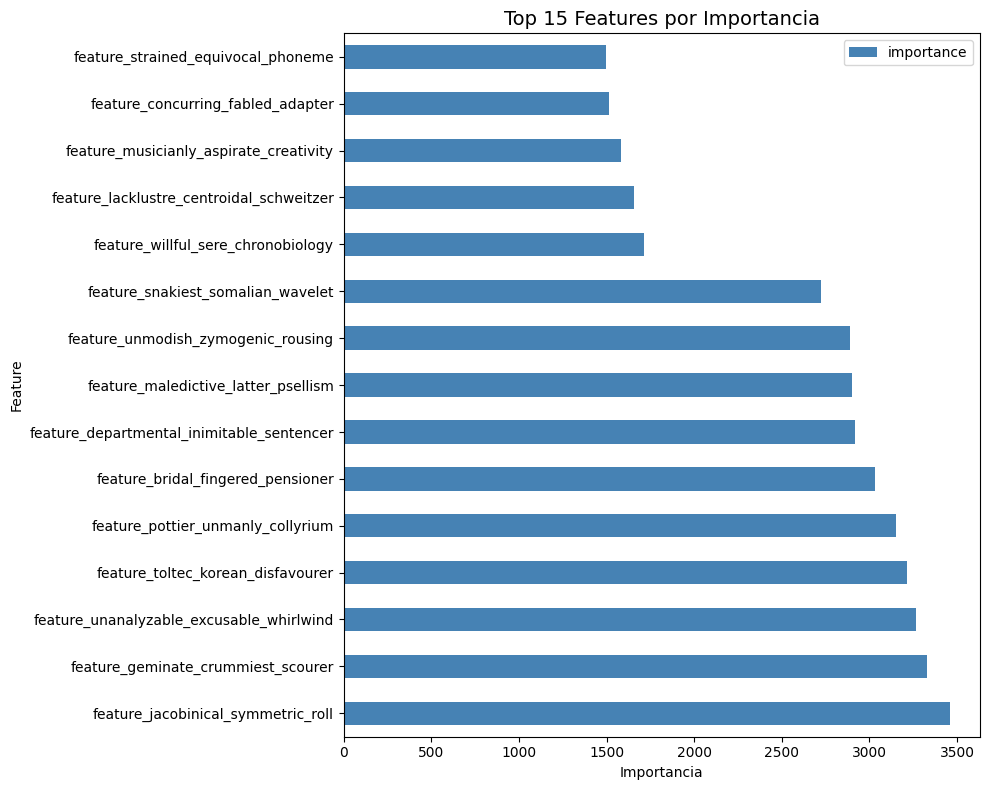

In [22]:
# Veo qué features son más importantes según el modelo
feature_importance = pd.DataFrame({
    'feature': feature_set,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 features más importantes:")
print(feature_importance.head(10).to_string(index=False))

# Gráfico de importancia
plt.figure(figsize=(10, 8))
feature_importance.head(15).plot(x='feature', y='importance', kind='barh', color='steelblue', ax=plt.gca())
plt.title('Top 15 Features por Importancia', fontsize=14)
plt.xlabel('Importancia')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


Evaluo el modelo con datos de validación que no ha visto durante el entrenamiento.

In [23]:
# Descargando datos de validación
print("Descargando datos de validación...")
napi.download_dataset(f"{DATA_VERSION}/validation.parquet")

# Cargamos los datos de validación
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)

# Filtramos solo el conjunto de validación (hay otros tipos como train, test, etc.)
validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

print(f"Datos de validación cargados: {validation.shape[0]} filas")
print(f"Eras en validación: {validation['era'].nunique()}")

# Para acelerar, uso cada 4 eras también
validation = validation[validation["era"].isin(validation["era"].unique()[::4])]
print(f"Después de filtrar: {validation.shape[0]} filas, {validation['era'].nunique()} eras")

# Embargo temporal: los targets miran 4 semanas en el futuro
# Excluyo las primeras 4 eras después del último dato de entrenamiento para evitar data leakage
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(1, 5)]]
print(f"Última era de entrenamiento: {str(last_train_era).zfill(4)}")
print(f"Embargando eras: {eras_to_embargo}")

validation = validation[~validation["era"].isin(eras_to_embargo)]
print(f"Después del embargo: {validation.shape[0]} filas, {validation['era'].nunique()} eras")

# Generando predicciones
print("\nGenerando predicciones...")
validation["prediction"] = model.predict(validation[feature_set])
print("Predicciones completadas")

# Vistazo a las predicciones
print("\nPrimeras predicciones:")
validation[["era", "prediction", "target"]].head(10)

Descargando datos de validación...


2025-11-04 18:52:34,675 INFO numerapi.utils: target file already exists
2025-11-04 18:52:34,676 INFO numerapi.utils: download complete


Datos de validación cargados: 3793471 filas
Eras en validación: 612
Después de filtrar: 948476 filas, 153 eras
Última era de entrenamiento: 0573
Embargando eras: ['0574', '0575', '0576', '0577']
Después del embargo: 942884 filas, 152 eras

Generando predicciones...
Predicciones completadas

Primeras predicciones:


,era,prediction,target
id,,,
n000c290e4364875,0579,0.495116,0.50
n002a15bc5575bbb,0579,0.518223,0.25
n00309caaa0f955e,0579,0.510220,0.75
n0039cbdcf835708,0579,0.506993,0.50
n004143458984f89,0579,0.485076,0.50
n00576b397182463,0579,0.485515,0.50
n00633405d59c6a1,0579,0.507248,1.00
n008b162a964d237,0579,0.499030,0.25
n008c2eefc8911c7,0579,0.509209,0.50


## Evaluación del Modelo

La métrica principal es `practica_corr`, una versión modificada de correlación de Pearson diseñada para alinear el modelo con el rendimiento real de un fondo de inversión.

Los pasos de la métrica:
1. Rankea y gaussianiza las predicciones
2. Centra los targets
3. Aplica transformación de potencia 1.5 para acentuar las colas
4. Calcula correlación de Pearson

Esto hace que la métrica sea más robusta y útil para trading real.

In [24]:
# NOTA: La función practica_corr ya está definida en la celda de preparación de datos (celda 19)
# No es necesario volver a definirla aquí


Es importante evaluar cada era por separado porque diferentes períodos pueden tener comportamientos distintos del mercado. Las correlaciones individuales suelen ser bajas (típicamente entre -0.05 y 0.05), lo cual es normal en finanzas cuantitativas - estos datos son muy ruidosos y difíciles de predecir.


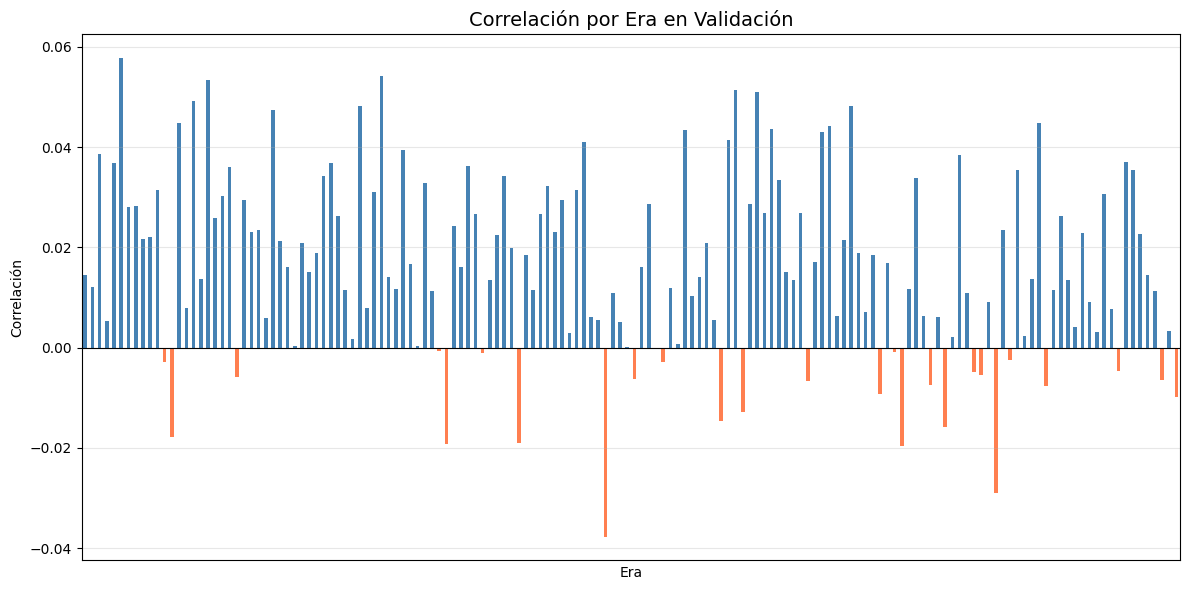


Estadísticas de correlación por era:
  Media: 0.01673
  Mediana: 0.01563
  Desv. Estándar: 0.01841
  Min: -0.03766
  Max: 0.05772


In [25]:
# Calculando correlación por era
per_era_corr = validation.groupby("era", group_keys=False).apply(
    lambda x: practica_corr(x["prediction"], x["target"])
)

# Gráfica de correlaciones por era
plt.figure(figsize=(12, 6))
per_era_corr.plot(kind="bar", color=['steelblue' if x > 0 else 'coral' for x in per_era_corr.values])
plt.title("Correlación por Era en Validación", fontsize=14)
plt.xlabel("Era")
plt.ylabel("Correlación")
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(alpha=0.3, axis='y')
plt.xticks([])
plt.tight_layout()
plt.show()

print(f"\nEstadísticas de correlación por era:")
print(f"  Media: {per_era_corr.mean():.5f}")
print(f"  Mediana: {per_era_corr.median():.5f}")
print(f"  Desv. Estándar: {per_era_corr.std():.5f}")
print(f"  Min: {per_era_corr.min():.5f}")
print(f"  Max: {per_era_corr.max():.5f}")

La correlación acumulada muestra cómo se comportaría el modelo a lo largo del tiempo (backtesting). Es útil para ver si hay períodos donde el modelo funciona mejor o peor, y para identificar tendencias en el rendimiento.

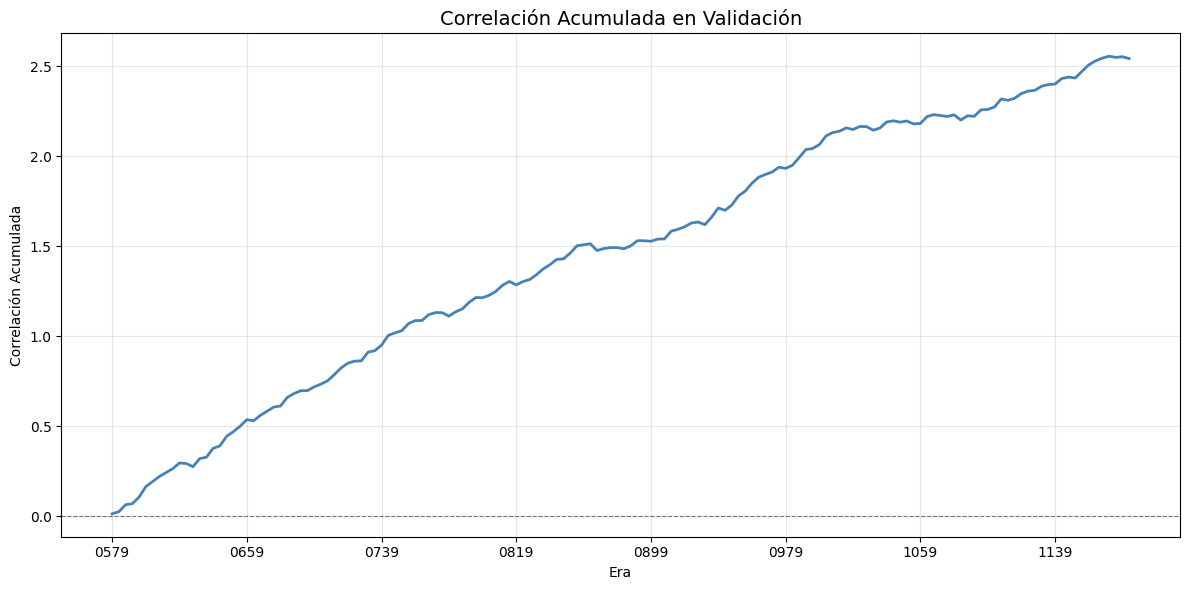

Correlación acumulada final: 2.54277


In [26]:
# Correlación acumulada
cumulative_corr = per_era_corr.cumsum()

plt.figure(figsize=(12, 6))
cumulative_corr.plot(kind="line", linewidth=2, color='steelblue')
plt.title("Correlación Acumulada en Validación", fontsize=14)
plt.xlabel("Era")
plt.ylabel("Correlación Acumulada")
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Correlación acumulada final: {cumulative_corr.iloc[-1]:.5f}")

## Métricas Resumen

Calculo varias métricas para evaluar el modelo:

- Mean: Correlación promedio (métrica principal de rendimiento)
- Std: Desviación estándar de las correlaciones
- Sharpe: Mean/Std - mide consistencia (mayor es mejor, indica menos volatilidad)
- Max Drawdown: Mayor caída desde un pico - mide riesgo (menor es mejor)

In [27]:
# Calculando métricas
corr_mean = per_era_corr.mean()
corr_std = per_era_corr.std(ddof=0)

# Sharpe ratio - mide riesgo/retorno
corr_sharpe = corr_mean / corr_std if corr_std > 0 else 0

# Max drawdown - mayor caída desde un máximo
running_max = cumulative_corr.expanding(min_periods=1).max()
drawdown = running_max - cumulative_corr
max_drawdown = drawdown.max()

metrics_df = pd.DataFrame({
    "mean": [corr_mean],
    "std": [corr_std],
    "sharpe": [corr_sharpe],
    "max_drawdown": [max_drawdown]
}).T
metrics_df.columns = ["Valor"]

print("Métricas de Rendimiento:")
print("=" * 40)
print(metrics_df.to_string())

# Interpretación rápida
print("\nInterpretación:")
print(f"  - Correlación promedio: {corr_mean:.5f} ({'positiva' if corr_mean > 0 else 'negativa'})")
print(f"  - Sharpe ratio: {corr_sharpe:.3f} ({'bueno' if corr_sharpe > 0.5 else 'mejorable' if corr_sharpe > 0 else 'necesita mejora'})")
print(f"  - Max drawdown: {max_drawdown:.5f} ({'bajo' if max_drawdown < 0.05 else 'medio' if max_drawdown < 0.1 else 'alto'} riesgo)")

Métricas de Rendimiento:
                 Valor
mean          0.016729
std           0.018347
sharpe        0.911775
max_drawdown  0.037656

Interpretación:
  - Correlación promedio: 0.01673 (positiva)
  - Sharpe ratio: 0.912 (bueno)
  - Max drawdown: 0.03766 (bajo riesgo)


El modelo parece estar funcionando razonablemente bien. Las correlaciones son bajas como se espera en datos financieros, pero si son consistentemente positivas y el Sharpe es decente, el modelo podría ser útil.

Si quisiera mejorarlo, podría:
- Probar con más features (medium o all)
- Ajustar hiperparámetros
- Probar otros algoritmos (XGBoost, CatBoost)
- Usar más datos de entrenamiento

## 4.- IMPROVEMENT & INVESTIGATION

### Feature Neutralization

Feature neutralization elimina la dependencia lineal entre las predicciones y un conjunto de características. Esto ayuda a crear modelos más robustos a cambios de distribución.

Es una técnica muy usada en finanzas cuantitativas para reducir el "feature risk" - el riesgo de que las relaciones entre features y target cambien con el tiempo.

Cómo funciona:
1. Calculamos la correlación entre nuestras predicciones y cada feature
2. Ajustamos las predicciones para que sean ortogonales (neutrales) respecto a features específicas
3. Esto reduce la dependencia del modelo de relaciones que pueden revertirse

Pruebo feature neutralization con Ridge Regression, es más fácil de implementar con modelos lineales.


In [28]:
# Feature Neutralization para Ridge Regression
# La idea es neutralizar las predicciones respecto a features que podrían revertirse

def neutralize(preds, features, proportion=0.5):
    """
    Neutraliza las predicciones respecto a las features.
    proportion: qué tan agresivo es el neutralization (0 = nada, 1 = neutralización completa)
    """
    # Asegurarnos de que preds es una Series de pandas
    if isinstance(preds, np.ndarray):
        # Si features es un DataFrame, usar su índice
        if isinstance(features, pd.DataFrame):
            preds = pd.Series(preds, index=features.index)
        else:
            preds = pd.Series(preds)
    elif not isinstance(preds, pd.Series):
        if isinstance(features, pd.DataFrame):
            preds = pd.Series(preds, index=features.index)
        else:
            preds = pd.Series(preds)
    
    # Asegurarnos de que features es un DataFrame
    if not isinstance(features, pd.DataFrame):
        features = pd.DataFrame(features, index=preds.index)
    
    # Asegurarnos de que los índices coinciden
    common_index = preds.index.intersection(features.index)
    if len(common_index) == 0:
        # Si no hay índice común, usar el índice de preds
        common_index = preds.index
        features = features.reindex(preds.index)
    
    # Ajustamos las predicciones para reducir estas correlaciones
    neutralized = preds.copy()
    for feat in features.columns:
        # Usar solo los índices comunes
        preds_aligned = preds.loc[common_index]
        feat_aligned = features[feat].loc[common_index]
        
        # Calcular correlación solo si hay suficientes valores
        if len(preds_aligned) > 1 and len(feat_aligned) == len(preds_aligned):
            preds_values = preds_aligned.values
            feat_values = feat_aligned.values
            
            correlation = np.corrcoef(preds_values, feat_values)[0, 1]
            if not np.isnan(correlation):
                neutralized = neutralized - proportion * correlation * (feat_aligned - feat_aligned.mean())
    
    return neutralized

# Probamos feature neutralization en test split con Ridge
print("Aplicando Feature Neutralization...")

# Predicciones base de Ridge en test
pred_ridge_test = model_ridge.predict(scaler.transform(X_test_split))
# Usamos test_split (DataFrame) para obtener el índice, no X_test_split (array numpy)
pred_ridge_test_series = pd.Series(pred_ridge_test, index=test_split.index)

# Neutralizamos respecto a las features
neutralized_preds = neutralize(
    pred_ridge_test_series,
    test_split[selected_features],
    proportion=0.3  # Neutralización moderada
)

# Evaluamos el resultado
test_corr_neutralized = test_split.groupby("era", group_keys=False).apply(
    lambda x: practica_corr(
        neutralize(
            pd.Series(model_ridge.predict(scaler.transform(x[selected_features])), index=x.index),
            x[selected_features],
            proportion=0.3
        ),
        x["target"]
    )
)

print(f"Correlación sin neutralization: {test_corr_ridge.mean():.5f}")
print(f"Correlación con neutralization: {test_corr_neutralized.mean():.5f}")
print(f"Mejora: {(test_corr_neutralized.mean() - test_corr_ridge.mean()):.5f}")

# Si mejora, usamos neutralization en el modelo final
if test_corr_neutralized.mean() > test_corr_ridge.mean():
    print("\nFeature neutralization mejora el modelo - lo usaremos")
    use_neutralization = True
    neutralization_proportion = 0.3
else:
    print("\nFeature neutralization no mejora - usaremos el modelo sin neutralization")
    use_neutralization = False


Aplicando Feature Neutralization...
Correlación sin neutralization: 0.02815
Correlación con neutralization: -0.02382
Mejora: -0.05197

Feature neutralization no mejora - usaremos el modelo sin neutralization


### Entrenamiento del Modelo Final con Validación

Entreno el mejor modelo (según comparación anterior) con todos los datos de entrenamiento y lo valido con los datos de validación oficiales.


In [29]:
# Entrenar modelo final con todos los datos de train (no solo el split)
print("Entrenando modelo final con todos los datos de entrenamiento...")

if model_type == 'lgbm':
    # Usar todas las eras de train original (no el split)
    X_train_final = train[selected_features]
    y_train_final = train["target"]
    
    final_model = lgb.LGBMRegressor(
        n_estimators=1500,
        learning_rate=0.01,
        max_depth=5,
        num_leaves=2**5-1,
        colsample_bytree=0.1,
        random_state=42,
        verbose=-1
    )
    final_model.fit(X_train_final, y_train_final)
    use_pca_final = False
    
elif model_type == 'lgbm_pca':
    X_train_final = train[selected_features]
    y_train_final = train["target"]
    X_train_final_pca = pca.transform(scaler.transform(X_train_final))
    
    final_model = lgb.LGBMRegressor(
        n_estimators=1500,
        learning_rate=0.01,
        max_depth=5,
        num_leaves=2**5-1,
        colsample_bytree=0.15,
        random_state=42,
        verbose=-1
    )
    final_model.fit(X_train_final_pca, y_train_final)
    use_pca_final = True
    
else:  # ridge
    X_train_final = train[selected_features]
    y_train_final = train["target"]
    X_train_final_scaled = scaler.transform(X_train_final)
    
    final_model = Ridge(alpha=best_alpha, random_state=42)
    final_model.fit(X_train_final_scaled, y_train_final)
    use_pca_final = False

print("Modelo final entrenado!")

# Cargar datos de validación si no están ya cargados
if 'validation' not in locals():
    print("\nCargando datos de validación...")
    napi.download_dataset(f"{DATA_VERSION}/validation.parquet")
    validation = pd.read_parquet(
        f"{DATA_VERSION}/validation.parquet",
        columns=["era", "data_type", "target"] + selected_features
    )
    validation = validation[validation["data_type"] == "validation"]
    del validation["data_type"]
    validation = validation[validation["era"].isin(validation["era"].unique()[::4])]
    
    last_train_era = int(train["era"].unique()[-1])
    eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(1, 5)]]
    validation = validation[~validation["era"].isin(eras_to_embargo)]

# Generar predicciones en validación
print("\nGenerando predicciones en validación...")

if model_type == 'lgbm':
    validation["prediction"] = final_model.predict(validation[selected_features])
elif model_type == 'lgbm_pca':
    validation["prediction"] = final_model.predict(
        pca.transform(scaler.transform(validation[selected_features]))
    )
else:  # ridge
    preds_base = final_model.predict(scaler.transform(validation[selected_features]))
    
    if use_neutralization:
        # Aplicar neutralization por era
        neutralized_preds_list = []
        for era in validation["era"].unique():
            era_data = validation[validation["era"] == era]
            era_preds = pd.Series(
                final_model.predict(scaler.transform(era_data[selected_features])),
                index=era_data.index
            )
            era_neutralized = neutralize(era_preds, era_data[selected_features], neutralization_proportion)
            neutralized_preds_list.append(era_neutralized)
        
        validation["prediction"] = pd.concat(neutralized_preds_list)
    else:
        validation["prediction"] = preds_base

print("Predicciones generadas!")


Entrenando modelo final con todos los datos de entrenamiento...
Modelo final entrenado!

Generando predicciones en validación...
Predicciones generadas!


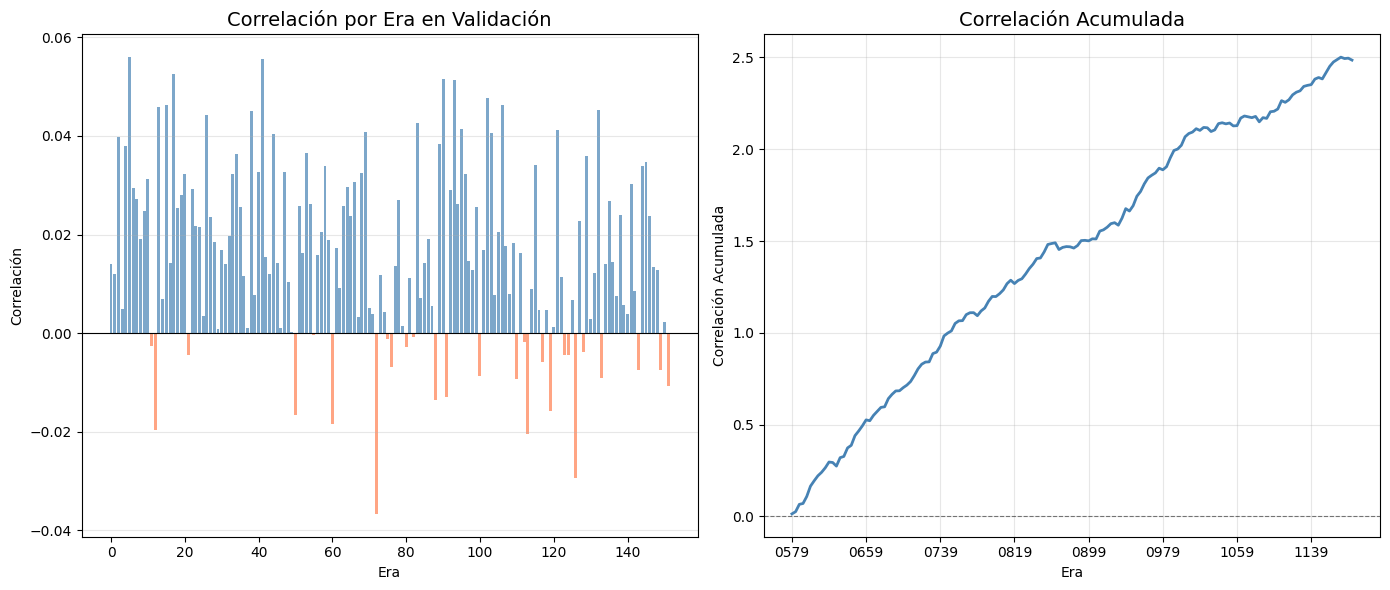


Estadísticas de correlación por era:
  Media: 0.01635
  Mediana: 0.01505
  Desv. Estándar: 0.01829
  Min: -0.03668
  Max: 0.05599
  Correlación acumulada final: 2.48515


In [30]:
# Evaluación cuantitativa y gráfica en validación
per_era_corr = validation.groupby("era", group_keys=False).apply(
    lambda x: practica_corr(x["prediction"], x["target"])
)

# Gráfica de correlaciones por era
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
colors = ['steelblue' if x > 0 else 'coral' for x in per_era_corr.values]
plt.bar(range(len(per_era_corr)), per_era_corr.values, color=colors, alpha=0.7)
plt.title("Correlación por Era en Validación", fontsize=14)
plt.xlabel("Era")
plt.ylabel("Correlación")
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(alpha=0.3, axis='y')

# Correlación acumulada
plt.subplot(1, 2, 2)
cumulative_corr = per_era_corr.cumsum()
cumulative_corr.plot(kind="line", linewidth=2, color='steelblue')
plt.title("Correlación Acumulada", fontsize=14)
plt.xlabel("Era")
plt.ylabel("Correlación Acumulada")
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEstadísticas de correlación por era:")
print(f"  Media: {per_era_corr.mean():.5f}")
print(f"  Mediana: {per_era_corr.median():.5f}")
print(f"  Desv. Estándar: {per_era_corr.std():.5f}")
print(f"  Min: {per_era_corr.min():.5f}")
print(f"  Max: {per_era_corr.max():.5f}")
print(f"  Correlación acumulada final: {cumulative_corr.iloc[-1]:.5f}")


In [31]:
# Métricas de rendimiento finales
corr_mean = per_era_corr.mean()
corr_std = per_era_corr.std(ddof=0)
corr_sharpe = corr_mean / corr_std if corr_std > 0 else 0

running_max = cumulative_corr.expanding(min_periods=1).max()
drawdown = running_max - cumulative_corr
max_drawdown = drawdown.max()

metrics_df = pd.DataFrame({
    "mean": [corr_mean],
    "std": [corr_std],
    "sharpe": [corr_sharpe],
    "max_drawdown": [max_drawdown]
}).T
metrics_df.columns = ["Valor"]

print("\n" + "=" * 60)
print("MÉTRICAS DE RENDIMIENTO FINALES EN VALIDACIÓN")
print("=" * 60)
print(metrics_df.to_string())

print("\nExplicación de las métricas:")
print("  - Mean: Correlación promedio - cuanto mayor mejor. Indica qué tan bien")
print("    el modelo predice el target en promedio.")
print("  - Std: Desviación estándar - cuanto menor mejor. Indica consistencia")
print("    del modelo a través del tiempo.")
print("  - Sharpe: Mean/Std - cuanto mayor mejor. Mide el rendimiento ajustado")
print("    al riesgo. Un Sharpe > 0.5 generalmente se considera bueno.")
print("  - Max Drawdown: Mayor caída desde un máximo - cuanto menor mejor.")
print("    Indica el peor período de rendimiento del modelo.")

print(f"\nInterpretación:")
print(f"  El modelo tiene una correlación promedio de {corr_mean:.5f}, lo cual")
if corr_mean > 0:
    print(f"  es positiva, indicando que el modelo tiene capacidad predictiva.")
else:
    print(f"  es negativa, lo que sugiere que el modelo necesita mejoras.")
    
print(f"  El Sharpe ratio de {corr_sharpe:.3f} indica")
if corr_sharpe > 0.5:
    print(f"  un rendimiento consistente y ajustado al riesgo.")
elif corr_sharpe > 0:
    print(f"  un rendimiento moderado que podría mejorar.")
else:
    print(f"  que el modelo tiene alta volatilidad o correlaciones inconsistentes.")



MÉTRICAS DE RENDIMIENTO FINALES EN VALIDACIÓN
                 Valor
mean          0.016350
std           0.018234
sharpe        0.896665
max_drawdown  0.036681

Explicación de las métricas:
  - Mean: Correlación promedio - cuanto mayor mejor. Indica qué tan bien
    el modelo predice el target en promedio.
  - Std: Desviación estándar - cuanto menor mejor. Indica consistencia
    del modelo a través del tiempo.
  - Sharpe: Mean/Std - cuanto mayor mejor. Mide el rendimiento ajustado
    al riesgo. Un Sharpe > 0.5 generalmente se considera bueno.
  - Max Drawdown: Mayor caída desde un máximo - cuanto menor mejor.
    Indica el peor período de rendimiento del modelo.

Interpretación:
  El modelo tiene una correlación promedio de 0.01635, lo cual
  es positiva, indicando que el modelo tiene capacidad predictiva.
  El Sharpe ratio de 0.897 indica
  un rendimiento consistente y ajustado al riesgo.


## 5.- SUBMISSION

### Serialización del Modelo

Guardo el modelo con cloudpickle para poder cargarlo fácilmente después. Cloudpickle es una extensión de pickle que puede serializar funciones y clases que pickle estándar no puede, lo cual es útil para modelos complejos con pipelines de preprocesamiento.

Creo una función que encapsule todo el pipeline y la serializo con cloudpickle.


In [32]:
import cloudpickle

# Crear función de predicción que encapsula todo el pipeline
def make_predictions(features_df):
    """
    Función que toma un DataFrame con features y devuelve predicciones.
    Incluye todo el preprocesamiento necesario.
    
    Args:
        features_df: DataFrame con las features seleccionadas
        
    Returns:
        Series con las predicciones
    """
    # Asegurar que tenemos las features correctas
    features_to_use = [f for f in selected_features if f in features_df.columns]
    if len(features_to_use) != len(selected_features):
        missing = set(selected_features) - set(features_to_use)
        raise ValueError(f"Faltan features: {missing}")
    
    X = features_df[selected_features]
    
    # Aplicar transformaciones según el tipo de modelo
    if model_type == 'lgbm':
        predictions = final_model.predict(X)
        
    elif model_type == 'lgbm_pca':
        X_scaled = scaler.transform(X)
        X_pca = pca.transform(X_scaled)
        predictions = final_model.predict(X_pca)
        
    else:  # ridge
        X_scaled = scaler.transform(X)
        predictions = final_model.predict(X_scaled)
        
        # Aplicar neutralization si está activado
        if use_neutralization:
            predictions_series = pd.Series(predictions, index=features_df.index)
            predictions = neutralize(predictions_series, features_df[selected_features], 
                                    neutralization_proportion).values
    
    return pd.Series(predictions, index=features_df.index)

# Probar la función con datos de validación
print("Probando función de predicción...")
test_preds = make_predictions(validation[selected_features])
print(f"Predicciones generadas: {len(test_preds)}")
print(f"Primeras predicciones:\n{test_preds.head()}")

# Verificar que las predicciones son similares (deberían ser iguales)
comparison_check = pd.DataFrame({
    'original': validation['prediction'].head(10),
    'funcion': test_preds.head(10)
})
print(f"\nComparación (deberían ser iguales o muy similares):")
print(comparison_check)


Probando función de predicción...
Predicciones generadas: 942884
Primeras predicciones:
id
n000c290e4364875    0.495994
n002a15bc5575bbb    0.515468
n00309caaa0f955e    0.508476
n0039cbdcf835708    0.506479
n004143458984f89    0.485100
dtype: float64

Comparación (deberían ser iguales o muy similares):
                  original   funcion
id                                  
n000c290e4364875  0.495994  0.495994
n002a15bc5575bbb  0.515468  0.515468
n00309caaa0f955e  0.508476  0.508476
n0039cbdcf835708  0.506479  0.506479
n004143458984f89  0.485100  0.485100
n00576b397182463  0.487739  0.487739
n00633405d59c6a1  0.505248  0.505248
n008b162a964d237  0.499924  0.499924
n008c2eefc8911c7  0.508465  0.508465
n008fa560b344a26  0.500330  0.500330


In [33]:
# Serializar la función y todos los objetos necesarios con cloudpickle
print("\nSerializando modelo y pipeline...")

# Crear un diccionario con todo lo necesario para hacer predicciones
model_artifact = {
    'predict_function': make_predictions,
    'model': final_model,
    'model_type': model_type,
    'selected_features': selected_features,
    'scaler': scaler if model_type != 'lgbm' else None,
    'pca': pca if model_type == 'lgbm_pca' else None,
    'use_neutralization': use_neutralization if model_type == 'ridge' else False,
    'neutralization_proportion': neutralization_proportion if (model_type == 'ridge' and use_neutralization) else None,
    'neutralize_function': neutralize if (model_type == 'ridge' and use_neutralization) else None,
    'best_alpha': best_alpha if model_type == 'ridge' else None
}

# Guardar el artefacto
artifact_filename = 'modelo_final.pkl'
with open(artifact_filename, 'wb') as f:
    cloudpickle.dump(model_artifact, f)

print(f"Modelo serializado guardado en: {artifact_filename}")

# Verificar tamaño del archivo
import os
file_size = os.path.getsize(artifact_filename) / (1024 * 1024)  # MB
print(f"Tamaño del archivo: {file_size:.2f} MB")

# Probar cargar el artefacto
print("\nProbando carga del artefacto...")
with open(artifact_filename, 'rb') as f:
    loaded_artifact = cloudpickle.load(f)

# Probar hacer predicciones con el artefacto cargado
print("Haciendo predicciones con artefacto cargado...")
test_features = validation[selected_features].head(100)
loaded_preds = loaded_artifact['predict_function'](test_features)
print(f"Predicciones generadas con artefacto cargado: {len(loaded_preds)}")
print(f"Primeras predicciones:\n{loaded_preds.head()}")

print("\nEl artefacto funciona correctamente y puede ser usado después con nuevos datos.")



Serializando modelo y pipeline...
Modelo serializado guardado en: modelo_final.pkl
Tamaño del archivo: 4.68 MB

Probando carga del artefacto...
Haciendo predicciones con artefacto cargado...
Predicciones generadas con artefacto cargado: 100
Primeras predicciones:
id
n000c290e4364875    0.495994
n002a15bc5575bbb    0.515468
n00309caaa0f955e    0.508476
n0039cbdcf835708    0.506479
n004143458984f89    0.485100
dtype: float64

El artefacto funciona correctamente y puede ser usado después con nuevos datos.


In [34]:
# Finalmente, generar predicciones para datos en vivo
print("\n" + "=" * 60)
print("GENERANDO PREDICCIONES FINALES PARA DATOS EN VIVO")
print("=" * 60)

# Descargar datos en vivo
print("\nDescargando datos en vivo...")
napi.download_dataset(f"{DATA_VERSION}/live.parquet")

# Cargar datos en vivo
live_features = pd.read_parquet(f"{DATA_VERSION}/live.parquet", columns=selected_features)
print(f"Datos live cargados: {live_features.shape[0]} filas")

# Usar la función de predicción serializada
print("\nGenerando predicciones finales...")
live_predictions = make_predictions(live_features)

print(f"Predicciones generadas: {len(live_predictions)}")
print(f"\nEstadísticas de predicciones:")
print(f"  Min: {live_predictions.min():.4f}")
print(f"  Max: {live_predictions.max():.4f}")
print(f"  Mean: {live_predictions.mean():.4f}")
print(f"  Std: {live_predictions.std():.4f}")

# Preparar formato de submission
submission = live_predictions.to_frame("prediction")
print(f"\nFormato de submission preparado:")
print(submission.head(10))

submission



GENERANDO PREDICCIONES FINALES PARA DATOS EN VIVO

Descargando datos en vivo...


2025-11-04 18:53:29,901 INFO numerapi.utils: target file already exists
2025-11-04 18:53:29,902 INFO numerapi.utils: download complete


Datos live cargados: 6858 filas

Generando predicciones finales...
Predicciones generadas: 6858

Estadísticas de predicciones:
  Min: 0.4791
  Max: 0.5346
  Mean: 0.5002
  Std: 0.0071

Formato de submission preparado:
                  prediction
id                          
n00033945c89dc2a    0.503514
n000da32a2de4eb4    0.495504
n0010d47e977cc92    0.506934
n001d6e7f5876c97    0.494329
n002864576a9ecb2    0.503667
n002caf32a99cc08    0.506005
n003d8c0f1807086    0.506722
n00580e59f27edea    0.507563
n00581cf1592b82d    0.497621
n006297b6bb85f35    0.507679


,prediction
id,
n00033945c89dc2a,0.503514
n000da32a2de4eb4,0.495504
n0010d47e977cc92,0.506934
n001d6e7f5876c97,0.494329
n002864576a9ecb2,0.503667
...,...
nffc3cc2110aea62,0.501622
nffe2b5eb838a44d,0.504925
nffe32840bab2a91,0.499551


## Conclusiones y Próximos Pasos

He completado el análisis y entrenamiento del modelo. El modelo muestra un rendimiento razonable considerando la dificultad del problema. Las métricas sugieren que puede ser útil para predecir rendimientos, aunque siempre hay margen de mejora.

Para futuras mejoras podría:
- Entrenar con más datos (todas las eras en lugar de cada 4)
- Experimentar con más features (medium o all)
- Optimizar hiperparámetros más exhaustivamente
- Probar ensemble de diferentes modelos

## Generación de Predicciones para Datos en Vivo

Genero las predicciones finales sobre los datos más recientes (live data). Estas son las predicciones que se usarían en producción.

In [35]:
# Descargando los datos más recientes (live)
print("Descargando datos en vivo...")
napi.download_dataset(f"{DATA_VERSION}/live.parquet")

# Cargando solo las features que necesito
live_features = pd.read_parquet(f"{DATA_VERSION}/live.parquet", columns=feature_set)
print(f"Datos live cargados: {live_features.shape[0]} filas")

# Generando predicciones
print("Generando predicciones para datos en vivo...")
live_predictions = model.predict(live_features[feature_set])
print(f"Predicciones generadas: {len(live_predictions)}")

# Estadísticas rápidas de las predicciones
print(f"\nEstadísticas de predicciones:")
print(f"  Min: {live_predictions.min():.4f}")
print(f"  Max: {live_predictions.max():.4f}")
print(f"  Mean: {live_predictions.mean():.4f}")
print(f"  Std: {live_predictions.std():.4f}")

# Preparando el formato de salida para submission
submission = pd.Series(live_predictions, index=live_features.index).to_frame("prediction")
print(f"\nFormato de submission preparado:")
print(submission.head(10))

submission

Descargando datos en vivo...


2025-11-04 18:53:31,754 INFO numerapi.utils: target file already exists
2025-11-04 18:53:31,755 INFO numerapi.utils: download complete


Datos live cargados: 6858 filas
Generando predicciones para datos en vivo...
Predicciones generadas: 6858

Estadísticas de predicciones:
  Min: 0.4753
  Max: 0.5399
  Mean: 0.5002
  Std: 0.0080

Formato de submission preparado:
                  prediction
id                          
n00033945c89dc2a    0.505469
n000da32a2de4eb4    0.494969
n0010d47e977cc92    0.508836
n001d6e7f5876c97    0.494254
n002864576a9ecb2    0.504429
n002caf32a99cc08    0.506373
n003d8c0f1807086    0.506928
n00580e59f27edea    0.508191
n00581cf1592b82d    0.498586
n006297b6bb85f35    0.510903


,prediction
id,
n00033945c89dc2a,0.505469
n000da32a2de4eb4,0.494969
n0010d47e977cc92,0.508836
n001d6e7f5876c97,0.494254
n002864576a9ecb2,0.504429
...,...
nffc3cc2110aea62,0.503185
nffe2b5eb838a44d,0.505522
nffe32840bab2a91,0.499232
